# Controlled comparison of labeling method with real data

In [1]:
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Union

import numpy as np
import pandas as pd
import json
import pysam
import cvxpy as cp
from tqdm import tqdm
import matplotlib.pyplot as plt

from utils import (
    filename2ctype,
    nested_defaultdict_to_dict,
    get_idx_from_sig,
    get_sig_from_idx,
    nrmse
)

## Miscellaneus utils

In [2]:
def extract_complete_dataset(reads_ds):
    """
    Create a complete dataset from a given reads_ds dataset
    by splitting long patterns into all possible subpatterns and storing the counts.
    """
    complete_dataset = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for ctype, length_dict in reads_ds.items():
        for read_length in sorted(length_dict.keys()):
            for start, pattern_counts in length_dict[read_length].items():
                for pattern, n_reads in pattern_counts.items():
                    # add the original pattern to the complete dataset
                    complete_dataset[ctype][len(pattern)][start][pattern] += n_reads
                    # split the pattern into all possible subpatterns
                    for sub_length in range(1, len(pattern)):
                        for sub_start in range(len(pattern) - sub_length + 1):
                            subpattern = pattern[sub_start : sub_start + sub_length]
                            if len(subpattern) == 0:
                                continue  # skip empty subpatterns
                            complete_dataset[ctype][len(subpattern)][start + sub_start][
                                subpattern
                            ] += n_reads
    return complete_dataset

In [3]:
def compute_num_reads_in_dataset(dataset):
    """
    Compute the total number of reads in a given dataset
    """
    total_reads = 0
    for ctype, length_dict in dataset.items():
        for read_length, start_dict in length_dict.items():
            for start, pattern_counts in start_dict.items():
                total_reads += sum(pattern_counts.values())
    return total_reads

In [4]:
def generate_bootstrap_sample_from_dataset(source_dataset, ratio=None, dataset_size_to_sample=None):
    """
    Generate a bootstrap sample from a given dataset by sampling with replacement the reads.
    """
    assert dataset_size_to_sample is not None or ratio is not None, "Either dataset_size_to_sample or ratio must be provided"
    size_source_dataset = compute_num_reads_in_dataset(source_dataset)
    if ratio is not None:
        assert 0 < ratio, "Ratio must be > 0 (can be > 1 for oversampling)"
        dataset_size_to_sample = int(size_source_dataset * ratio)
    
    # create a list of all reads in the source dataset
    unique_reads = []
    counts_per_read = []
    for ctype, length_dict in source_dataset.items():
        for read_length, start_dict in length_dict.items():
            for start, pattern_counts in start_dict.items():
                for pattern, n_reads in pattern_counts.items():
                    unique_reads.append((ctype, read_length, start, pattern))
                    counts_per_read.append(n_reads)
    counts_per_read = np.array(counts_per_read)

    # sample with replacement the reads
    sampled_indices = np.random.choice(
        len(unique_reads), size=dataset_size_to_sample, replace=True, p=counts_per_read / counts_per_read.sum()
    )
    sampled_reads = [unique_reads[i] for i in sampled_indices]

    # create the bootstrap sample dataset
    bootstrap_sample_dataset = defaultdict(
        lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
    )
    for ctype, read_length, start, pattern in sampled_reads:
        bootstrap_sample_dataset[ctype][read_length][start][pattern] += 1
    return bootstrap_sample_dataset

In [5]:
def compute_counts_sig_per_ctype_from_dataset(dataset, sig_positions, selected_ctypes_, n_ctypes):
    """
    Compute the counts of signatures per ctype from a given dataset.
    """
    counts_sig_per_ctype = {}
    for start, read_lengths in sig_positions.items():
        counts_sig_per_ctype[start] = {}
        for read_length in read_lengths:
            counts_sig_per_ctype[start][read_length] = np.zeros(
                (n_ctypes, 2**read_length), dtype=int
            )
            for ctype_idx, ctype in enumerate(selected_ctypes_):
                pattern_counts = dataset[ctype][read_length][start]
                for pattern, n_reads in pattern_counts.items():
                    pattern_idx = get_idx_from_sig(pattern)
                    counts_sig_per_ctype[start][read_length][
                        ctype_idx, pattern_idx
                    ] += n_reads
    return counts_sig_per_ctype

In [6]:
def compute_pgt_sig_prior_from_counts(counts_sig_per_ctype):
    """
    Compute the prior probabilities of signatures per ctype from the counts of signatures.
    """
    pgt_sig_prior = {}
    for start, read_lengths in signature_positions.items():
        pgt_sig_prior[start] = {}
        for read_length in read_lengths:
            counts_sig_per_ctype_ = counts_sig_per_ctype[start][read_length]
            pgt_sig_prior[start][read_length] = (
                counts_sig_per_ctype_.sum(axis=0) / counts_sig_per_ctype_.sum()
            )
    return pgt_sig_prior

In [7]:
def compute_nrmse_per_sig_length(
    predicted_proba_sig_per_ctype: Dict[int, Dict[int, np.ndarray]], true_proba_sig_per_ctype: Dict[int, Dict[int, np.ndarray]], counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]]=None, count_threshold_per_ctype: int=None
):
    """
    Compute the normalized root mean square error (NRMSE) between the predicted and true probabilities of signatures per ctype,
    for a whole set of signature positions (ie start and read_length combinations).
    The average is computed per signature length, to avoid confusion.
    
    It is possible to provide a counts_sig_per_ctype and a count_threshold_per_ctype to filter out the signature positions with too low counts
    for a given ctype.
    """
    nrmse_list_per_length = defaultdict(list)
    for start, read_lengths in predicted_proba_sig_per_ctype.items():
        for read_length, predicted_proba in read_lengths.items():
            true_proba = true_proba_sig_per_ctype[start][read_length]
            if count_threshold_per_ctype is not None:
                if counts_sig_per_ctype is None:
                    raise ValueError("If count_threshold_per_ctype is provided, counts_sig_per_ctype must also be provided")
                tmp_ctype_counts = counts_sig_per_ctype[start][read_length].sum(axis=1)
                ctype_mask = tmp_ctype_counts >= count_threshold_per_ctype
                predicted_proba = predicted_proba[ctype_mask]
                true_proba = true_proba[ctype_mask]
            # Skip computing NRMSE if there's no data after filtering
            if len(predicted_proba) == 0:
                continue
            nrmse_ = nrmse(true_proba, predicted_proba)
            nrmse_list_per_length[read_length].append(nrmse_)
    avg_nrmse_per_length = {read_length: np.mean(nrmse_list) for read_length, nrmse_list in nrmse_list_per_length.items() if len(nrmse_list) > 0}
    return avg_nrmse_per_length

## Methods definitions

In [8]:
# Naive soft labels without pooling
def naive_sl_without_pooling(counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]]):
    """
    Compute P(sig | ctype) by normalizing the counts of signatures per ctype.
    """
    return {
        start: {
            read_length: counts / counts.sum(axis=1, keepdims=True)
            for read_length, counts in read_lengths.items()
        }
        for start, read_lengths in counts_sig_per_ctype.items()
    }


def naive_sl_without_pooling_ctype_given_sig(
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
):
    """
    Compute P(ctype | sig) by normalizing the counts of signatures per ctype.
    """
    return {
        start: {
            read_length: (counts / counts.sum(axis=0, keepdims=True)).T
            for read_length, counts in read_lengths.items()
        }
        for start, read_lengths in counts_sig_per_ctype.items()
    }

In [9]:
# Naive soft labels with pooling
def jaccard_distance(sig1_data, sig2_data) -> float:
    """
    Compute the Jaccard distance between two signatures represented as (start, length, sig_idx).
    First we reconstruct the real signatures from the signature indices, then we compute the
    Jaccard distance between the two sets of CpG positions with status 1.
    """
    start1, len1, sig_idx1 = sig1_data
    start2, len2, sig_idx2 = sig2_data
    sig1 = get_sig_from_idx(sig_idx1, len1)
    sig2 = get_sig_from_idx(sig_idx2, len2)
    complete_sig1 = set((start1 + i, int(state)) for i, state in enumerate(sig1))
    complete_sig2 = set((start2 + i, int(state)) for i, state in enumerate(sig2))
    intersection = complete_sig1 & complete_sig2
    union = complete_sig1 | complete_sig2
    return 1 - len(intersection) / len(union) if union else 0.0


def naive_sl_with_pooling(
    counts_sig_per_ctype: Dict[int, Dict[int, np.ndarray]],
    pgt_sig_prior: Dict[int, Dict[int, np.ndarray]],
    dist_threshold: float = 0.41,
    min_counts: int = 30,
):
    """
    Compute P(sig | ctype) for every signature by first computing
    P(ctype | sig) (using soft labels with pooling) and then converting it
    to P(sig | ctype) using the pseudo ground truth prior P(sig).
    """
    # first we construct the list of all signatures with their start, length and index
    all_signatures = []
    for start, read_lengths in signature_positions.items():
        for read_length in read_lengths:
            n_signatures = 2**read_length
            for sig_idx in range(n_signatures):
                all_signatures.append((start, read_length, sig_idx))

    # then we compute the pairwise Jaccard distances between all signatures
    n_all_signatures = len(all_signatures)
    jaccard_distances = np.zeros((n_all_signatures, n_all_signatures))
    for i in range(n_all_signatures):
        for j in range(i + 1, n_all_signatures):
            jaccard_distances[i, j] = jaccard_distance(
                all_signatures[i], all_signatures[j]
            )
            jaccard_distances[j, i] = jaccard_distances[i, j]

    # for all signatures, we iterate over all signatures by ascending order of jacccard distance
    # and we pool the signatures that are within the distance threshold until
    # we reach the minimum counts threshold
    pooled_counts = np.zeros((n_all_signatures, N_CTYPES), dtype=int)
    for sig_global_idx, (start, read_length, sig_idx) in enumerate(all_signatures):
        ordered_closed_signatures = np.argsort(jaccard_distances[sig_global_idx])
        for close_sig_global_idx in ordered_closed_signatures:
            close_start, close_read_length, close_sig_idx = all_signatures[
                close_sig_global_idx
            ]
            if jaccard_distances[sig_global_idx, close_sig_global_idx] > dist_threshold:
                break
            pooled_counts[sig_global_idx] += counts_sig_per_ctype[close_start][
                close_read_length
            ][:, close_sig_idx]
            if pooled_counts[sig_global_idx].sum() >= min_counts:
                break

    # now compute the naive soft labels P(ctype | sig) by normalizing the pooled counts
    naive_sl_with_pooling_ctype_given_sig = {}
    naive_sl_with_pooling_sig_given_ctype = {}
    for start, read_lengths in signature_positions.items():
        naive_sl_with_pooling_ctype_given_sig[start] = {}
        naive_sl_with_pooling_sig_given_ctype[start] = {}
        for read_length in read_lengths:
            n_signatures = 2**read_length
            naive_sl_with_pooling_ctype_given_sig[start][read_length] = np.zeros(
                (n_signatures, N_CTYPES)
            )

            # compute the naive soft labels P(ctype | sig) by normalizing the pooled counts
            for sig_idx in range(n_signatures):
                sig_global_idx = all_signatures.index((start, read_length, sig_idx))
                naive_sl_with_pooling_ctype_given_sig[start][read_length][sig_idx] = (
                    pooled_counts[sig_global_idx] / pooled_counts[sig_global_idx].sum()
                    if pooled_counts[sig_global_idx].sum() > 0
                    else 0
                )

            # compute the naive soft labels P(sig | ctype) by converting P(ctype | sig)
            # using the pseudo ground truth prior P(sig)
            tmp_sig_prior = pgt_sig_prior[start][read_length]
            proba_sig_given_ctype = (
                naive_sl_with_pooling_ctype_given_sig[start][read_length]
                * tmp_sig_prior.reshape(-1, 1)
            )
            proba_sig_given_ctype= proba_sig_given_ctype / proba_sig_given_ctype.sum(
                axis=0, keepdims=True
            )
            naive_sl_with_pooling_sig_given_ctype[start][read_length] = proba_sig_given_ctype.T



    return naive_sl_with_pooling_sig_given_ctype, naive_sl_with_pooling_ctype_given_sig

## Data preparation

### Selection of the ctypes and DMRs

First we load the file containing the coverage per ctype per dmr.

In [10]:
df_coverage_per_ctype_per_dmr = pd.read_csv(Path("./data/region_coverage.csv"))
df_coverage_per_ctype_per_dmr.columns = [
    col if col != "Ovary+Endom-Ep" else "Ovary-Ep"
    for col in df_coverage_per_ctype_per_dmr.columns
]
atlas = pd.read_csv(Path("../../Data/Atlas.U25.l4.hg38.full.tsv"), sep="\t")
# add target column to df_coverage_per_ctype_per_dmr
map_region_key_to_target = atlas.set_index(["chr", "start", "end"])["target"].to_dict()
df_coverage_per_ctype_per_dmr["target"] = df_coverage_per_ctype_per_dmr.apply(
    lambda row: map_region_key_to_target.get((row["chr"], row["start"], row["end"])),
    axis=1,
)

labels_dict = json.load(open(Path("../../App/labels_dict.json"), "r", encoding="utf-8"))
labels_dict = {int(k): v for k, v in labels_dict.items()}
labels_list = [labels_dict[i] for i in range(len(labels_dict))]

Now we want to find the N ctypes and a dmr $d^c$ specific to cell type $c$ such that the minimum coverage of all N ctypes (including $c$) is maximized across all dmr.

In [11]:
N_CTYPES = 2
best_dmr_idx = None
best_min_coverage = -1
best_ctypes = None
for dmr_idx, row in df_coverage_per_ctype_per_dmr.iterrows():
    coverage_per_ctype = row[labels_list].values
    # find the N ctypes with the highest coverage
    top_n_ctypes_idx = np.argsort(coverage_per_ctype)[-N_CTYPES:]
    if row["target"] not in labels_list:
        continue
    target_ctype_idx = labels_list.index(row["target"])
    if target_ctype_idx not in top_n_ctypes_idx:
        top_n_ctypes_idx = np.append(top_n_ctypes_idx[1:], target_ctype_idx)
    min_coverage = coverage_per_ctype[top_n_ctypes_idx].min()
    if min_coverage > best_min_coverage:
        best_min_coverage = min_coverage
        best_dmr_idx = dmr_idx
        best_ctypes = [labels_list[i] for i in top_n_ctypes_idx]
print(
    f"Best dmr: {best_dmr_idx}, Best ctypes: {best_ctypes}, Best min coverage: {best_min_coverage}"
)
print(
    f"Expected number of reads in the raw dataset: {df_coverage_per_ctype_per_dmr.loc[best_dmr_idx, best_ctypes].sum()}"
)

Best dmr: 563, Best ctypes: ['Endothel', 'Blood-T'], Best min coverage: 5129
Expected number of reads in the raw dataset: 10454


In [12]:
selected_ctypes = best_ctypes
selected_dmr_idx = best_dmr_idx
DMR_START_CPG = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "startCpG"]
DMR_FETCH_START = DMR_START_CPG - 50
DMR_END_CPG = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "endCpG"]
DMR_CHR = df_coverage_per_ctype_per_dmr.loc[selected_dmr_idx, "chr"]
print(
    df_coverage_per_ctype_per_dmr.loc[
        selected_dmr_idx,
        ["chr", "start", "end", "startCpG", "endCpG", "target"] + selected_ctypes,
    ]
)

chr             chr11
start       118341599
end         118342558
startCpG     17571299
endCpG       17571310
target        Blood-T
Endothel         5129
Blood-T          5325
Name: 563, dtype: object


### Extraction of reads

Reads are organized in a nested dictionary. The first level of the dictionnary is the cell type, the second level is number of CpG sites in the reads, and the third level are the individual starting positions. The values are dictionaries mapping the pattern of methylation to the number of reads with that pattern.
For instance:

```python
{
    "Blood-T": {
        3: {
            100: {
                "CCC": 10,
                "CT.": 5,
                "T.C": 20
            },
        }
    }
}
```

We first extract the raw reads from the files (so the pattern may contain unknown values).

We then split the reads with unknown values into smaller reads (separated by the unknown values).

Finally, we create an additional "complete" dataset where we add to the reads of size n all the subset of reads with size > n. This dataset is more complete, but it should only be used position per position (otherwise there will be double counting).

In [13]:
# get the list of files paths per ctype
PATH_TO_DATA = Path(
    "/staging/leuven/stg_00118/methylDL/data/loyfer2023/hg38/data/GSE186458"
)
files_per_ctype = defaultdict(list)
for file in PATH_TO_DATA.glob("*.pat.gz"):
    ctype = filename2ctype(file.name)
    if ctype in selected_ctypes:
        files_per_ctype[ctype].append(file)
files_per_ctype = dict(files_per_ctype)

In [14]:
# Extract the raw reads dataset for the selected dmr and selected ctypes
raw_reads_dataset = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
)
n_loops = sum(len(files) for files in files_per_ctype.values())
with tqdm(total=n_loops, desc="Extracting reads") as pbar:
    for ctype, files in files_per_ctype.items():
        for file in files:
            csi_file_path = str(file) + ".csi"
            tbx = pysam.TabixFile(str(file), index=csi_file_path)
            for row in tbx.fetch(DMR_CHR, DMR_FETCH_START, DMR_END_CPG + 1):
                parts = row.split("\t")
                read_start = int(parts[1])
                pattern = parts[2]
                n_reads = int(parts[3])
                read_end = read_start + len(pattern)  # exclusive
                # crop the read to the dmr region
                if read_end < DMR_START_CPG:
                    continue  # the read ends before the dmr start
                if read_start >= DMR_END_CPG:
                    continue  # the read starts after the dmr end
                cropped_pattern_start = max(read_start, DMR_START_CPG)
                cropped_pattern_end = min(read_end, DMR_END_CPG)
                cropped_pattern = pattern[
                    cropped_pattern_start
                    - read_start : cropped_pattern_end
                    - read_start
                ]
                if len(cropped_pattern) == 0:
                    continue  # the read does not overlap with the dmr
                # update the count of the cropped pattern in the raw reads dataset
                cropped_pattern = cropped_pattern.replace("C", "1").replace("T", "0")
                raw_reads_dataset[ctype][len(cropped_pattern)][cropped_pattern_start][
                    cropped_pattern
                ] += n_reads
                pbar.update(1)
# raw_reads_dataset = nested_defaultdict_to_dict(raw_reads_dataset)
n_reads_in_raw_dataset = compute_num_reads_in_dataset(raw_reads_dataset)
print(f"Number of reads in raw dataset: {n_reads_in_raw_dataset}")

Extracting reads: 2428it [00:00, 12326.41it/s]          

Number of reads in raw dataset: 10454


In [15]:
# Create the original read dataset by splitting the patterns at the unknown positions "."
og_dataset = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
)
for ctype, length_dict in raw_reads_dataset.items():
    for read_length in sorted(length_dict.keys()):  # start from the shorted reads
        for start, pattern_counts in length_dict[read_length].items():
            for pattern, n_reads in pattern_counts.items():
                # split the pattern at the unknown positions "."
                subpatterns = pattern.split(".")
                subpattern_starts = []
                current_pos = start
                for subpattern in subpatterns:
                    subpattern_starts.append(current_pos)
                    current_pos += len(subpattern)
                # update the count of the subpatterns in the reads dataset
                for subpattern, subpattern_start in zip(subpatterns, subpattern_starts):
                    if len(subpattern) == 0:
                        continue  # skip empty subpatterns
                    og_dataset[ctype][len(subpattern)][subpattern_start][
                        subpattern
                    ] += n_reads
n_reads_in_og_dataset = compute_num_reads_in_dataset(og_dataset)
print(
    f"Number of reads in original dataset (reads splitted at unknown positions): {n_reads_in_og_dataset}"
)

Number of reads in original dataset (reads splitted at unknown positions): 10617


In [16]:
# Create a complete dataset by splitting long patterns into all possible subpatterns and storing the counts
complete_og_dataset = extract_complete_dataset(og_dataset)
print(
    f"Number of reads in complete original dataset (reads splitted at unknown positions and long patterns splitted into all possible subpatterns): {compute_num_reads_in_dataset(complete_og_dataset)}"
)

Number of reads in complete original dataset (reads splitted at unknown positions and long patterns splitted into all possible subpatterns): 32400


Now we create the dict of all pairs (pattern start, pattern length) (over all ctypes), which 
represent the possible positions of signatures.

In [17]:
# first we identify the start_positions common to all ctypes
start_positions_per_ctype = defaultdict(set)
for ctype, length_dict in complete_og_dataset.items():
    for read_length, start_dict in length_dict.items():
        for start in start_dict.keys():
            start_positions_per_ctype[ctype].add(start)
common_start_positions = set.intersection(*start_positions_per_ctype.values())

# then we identify the (start, read_length) pairs common to all ctypes, which represent the possible positions of signatures
signature_positions_per_ctype = defaultdict(lambda: defaultdict(set))
for ctype, length_dict in complete_og_dataset.items():
    for read_length, start_dict in length_dict.items():
        for start in start_dict.keys():
            if start not in common_start_positions:
                continue
            signature_positions_per_ctype[ctype][start].add(read_length)
signature_positions = defaultdict(set)
for start in common_start_positions:
    signature_positions[start] = set.intersection(
        *[signature_positions_per_ctype[ctype][start] for ctype in selected_ctypes]
    )
signature_positions = nested_defaultdict_to_dict(signature_positions)
del common_start_positions
del start_positions_per_ctype
del signature_positions_per_ctype
print("Signature positions (pattern start, pattern length) pairs common to all ctypes: ")
signature_positions

Signature positions (pattern start, pattern length) pairs common to all ctypes: 


{17571299: {1, 2, 3, 4, 5},
 17571300: {1, 2, 3, 4},
 17571301: {1, 2, 3},
 17571302: {1, 2, 3},
 17571303: {1, 2},
 17571304: {1, 2, 3},
 17571305: {1, 2, 3, 4},
 17571306: {1, 2, 3, 4},
 17571307: {1, 2, 3},
 17571308: {1, 2},
 17571309: {1}}

## Construction of pseudo ground truth conditional distributions

### With naive soft labels without pooling

We can construct a pseudo ground truth (PGT) for both P(signature | ctype) and P(ctype | signature) simply by counting (using the complete dataset because there are no pooling of counts between signatures).

In [18]:
# compute counts of signatures per ctype
complete_og_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
    complete_og_dataset,
    signature_positions,
    selected_ctypes,
    N_CTYPES
)  # with the complete dataset
og_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
    og_dataset,
    signature_positions,
    selected_ctypes,
    N_CTYPES
)  # with the reads dataset


# compute the PGT P(s)
complete_og_pgt_sig_prior = compute_pgt_sig_prior_from_counts(
    complete_og_counts_sig_per_ctype
)  # with the complete dataset
og_pgt_sig_prior = compute_pgt_sig_prior_from_counts(
    og_counts_sig_per_ctype
)  # with the reads dataset

# compute the naive soft labels
pgt_naive_sl_sig_given_ctype = naive_sl_without_pooling(
    complete_og_counts_sig_per_ctype
)
# (warning is expected here as signatures with zero counts in all ctypes will lead to division by zero)
pgt_naive_sl_ctype_given_sig = naive_sl_without_pooling_ctype_given_sig(
    complete_og_counts_sig_per_ctype
)

/tmp/ipykernel_90238/3944075623.py:23: RuntimeWarning: invalid value encountered in divide
  read_length: (counts / counts.sum(axis=0, keepdims=True)).T


In [19]:
# Manual verification that we can go from P(sig | ctype) to P(ctype | sig) using the prior P(ctype)
tmp_start = 17571299
tmp_len = 4
tmp_ctype_prior = (
    complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum(axis=1)
    / complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum()
)
a = pgt_naive_sl_sig_given_ctype[tmp_start][tmp_len] * tmp_ctype_prior[:, np.newaxis]
a = a / a.sum(axis=0, keepdims=True)
print(
    f"Test that P(sig | ctype) and P(ctype | sig) are consistent : {np.isclose(a, pgt_naive_sl_ctype_given_sig[tmp_start][tmp_len].T, equal_nan=True).all()}"
)

Test that P(sig | ctype) and P(ctype | sig) are consistent : True


/tmp/ipykernel_90238/789146882.py:9: RuntimeWarning: invalid value encountered in divide
  a = a / a.sum(axis=0, keepdims=True)


In [20]:
# Manual verification that we can go from P(ctype | sig) to P(sig | ctype) using the prior P(sig)
tmp_start = 17571299
tmp_len = 4
tmp_sig_prior = (
    complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum(axis=0)
    / complete_og_counts_sig_per_ctype[tmp_start][tmp_len].sum()
)
b = np.nan_to_num(
    pgt_naive_sl_ctype_given_sig[tmp_start][tmp_len] * tmp_sig_prior.reshape(-1, 1), 10
)
b = b / b.sum(axis=0, keepdims=True)
print(
    f"Test that P(ctype | sig) and P(sig | ctype) are consistent : {np.isclose(b, pgt_naive_sl_sig_given_ctype[tmp_start][tmp_len].T, equal_nan=True).all()}"
)

Test that P(ctype | sig) and P(sig | ctype) are consistent : True


## Evaluation of the different methods to approximate the ground truth conditional distributions

Methods can either be compared through their estimation of P(signature | ctype) or P(ctype | signature).
We saw previously that in the ground truth, these two conditional distributions are related through the prior distributions of ctype and signature.

Therefore, we choose to evaluate the methods by comparing their estimation of P(signature | ctype) (because this is the natural output of most of the methods).
In the specific case of the naive soft labels with pooling, which directly estimates P(ctype | signature), we use the PGT prior distributions to convert it to P(signature | ctype) and then compare it to the PGT of P(signature | ctype).

### Experiment 1 : comparison of the naive soft labels with and without pooling

In [21]:
bootstrap_dataset = generate_bootstrap_sample_from_dataset(
    og_dataset, ratio=1.0
)
bootstrap_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
    bootstrap_dataset,
    signature_positions,
    selected_ctypes,
    N_CTYPES
)
naive_sl_with_pooling_sig_given_ctype, _ = naive_sl_with_pooling(
    bootstrap_counts_sig_per_ctype,
    og_pgt_sig_prior,
)
naive_sl_without_pooling_sig_given_ctype_bootstrap = naive_sl_without_pooling(
    bootstrap_counts_sig_per_ctype
)

/tmp/ipykernel_90238/3944075623.py:8: RuntimeWarning: invalid value encountered in divide
  read_length: counts / counts.sum(axis=1, keepdims=True)


In [26]:
N_BOOTSTRAP_SAMPLES = 200
ratio_grid = np.array([0.01, 0.5, 1.0, 2.0, 5.0])
count_threshold_per_ctype_for_nrmse = 1
n_ratios_to_test = len(ratio_grid)
size_og_dataset = compute_num_reads_in_dataset(og_dataset)
dataset_sizes_grid = np.array([int(size_og_dataset * ratio) for ratio in ratio_grid])
results_per_size_per_read_length_per_method = {ds: {i: {
    "naive_sl_without_pooling_complete_data": [],
    "naive_sl_without_pooling": [],
    "naive_sl_with_pooling": [],
} for i in range(1, 6)} for ds in dataset_sizes_grid}
n_loops = n_ratios_to_test * N_BOOTSTRAP_SAMPLES
with tqdm(total=n_loops, desc="Bootstrap sampling and computing NRMSE") as pbar:
    for ds_idx, dataset_size in enumerate(dataset_sizes_grid):
        for sim_id in range(N_BOOTSTRAP_SAMPLES):
            # sample data
            bootstrap_dataset = generate_bootstrap_sample_from_dataset(
                og_dataset, dataset_size_to_sample=dataset_size
            )
            bootstrap_complete_dataset = extract_complete_dataset(bootstrap_dataset)
            bootstrap_counts_sig_per_ctype = compute_counts_sig_per_ctype_from_dataset(
                bootstrap_dataset,
                signature_positions,
                selected_ctypes,
                N_CTYPES
            )
            bootstrap_counts_sig_per_ctype_complete_data = compute_counts_sig_per_ctype_from_dataset(
                bootstrap_complete_dataset,
                signature_positions,
                selected_ctypes,
                N_CTYPES
            )

            # compute soft labels
            naive_sl_without_pooling_sig_given_ctype_normal_data = naive_sl_without_pooling(
                bootstrap_counts_sig_per_ctype
            )
            naive_sl_without_pooling_sig_given_ctype_complete_data = naive_sl_without_pooling(
                bootstrap_counts_sig_per_ctype_complete_data
            )
            naive_sl_with_pooling_sig_given_ctype, _ = naive_sl_with_pooling(
                    bootstrap_counts_sig_per_ctype,
                    og_pgt_sig_prior,
            )

            nrmse_without_pooling_complete_data = compute_nrmse_per_sig_length(
                naive_sl_without_pooling_sig_given_ctype_complete_data,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype_complete_data,
                count_threshold_per_ctype=count_threshold_per_ctype_for_nrmse
            )
            nrmse_without_pooling_normal_data = compute_nrmse_per_sig_length(
                naive_sl_without_pooling_sig_given_ctype_normal_data,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                count_threshold_per_ctype=count_threshold_per_ctype_for_nrmse
            )
            nrmse_with_pooling = compute_nrmse_per_sig_length(
                naive_sl_with_pooling_sig_given_ctype,
                pgt_naive_sl_sig_given_ctype,
                counts_sig_per_ctype=bootstrap_counts_sig_per_ctype,
                count_threshold_per_ctype=count_threshold_per_ctype_for_nrmse
            )

            for read_length in range(1, 6):
                if read_length in nrmse_without_pooling_complete_data:
                    results_per_size_per_read_length_per_method[dataset_size][read_length]["naive_sl_without_pooling_complete_data"].append(
                        nrmse_without_pooling_complete_data[read_length]
                    )
                if read_length in nrmse_without_pooling_normal_data:
                    results_per_size_per_read_length_per_method[dataset_size][read_length]["naive_sl_without_pooling"].append(
                        nrmse_without_pooling_normal_data[read_length]
                    )
                if read_length in nrmse_with_pooling:
                    results_per_size_per_read_length_per_method[dataset_size][read_length]["naive_sl_with_pooling"].append(
                        nrmse_with_pooling[read_length]
                    )
            pbar.update(1)


Bootstrap sampling and computing NRMSE:   0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_90238/3944075623.py:8: RuntimeWarning: invalid value encountered in divide
  read_length: counts / counts.sum(axis=1, keepdims=True)
/tmp/ipykernel_90238/1712405989.py:94: RuntimeWarning: invalid value encountered in divide
  proba_sig_given_ctype= proba_sig_given_ctype / proba_sig_given_ctype.sum(
Bootstrap sampling and computing NRMSE: 100%|██████████| 1000/1000 [03:07<00:00,  5.33it/s]


In [27]:
# aggregate data in a 
mean_nrmse_per_method_per_read_length_per_size = defaultdict(lambda: defaultdict(list))
std_nrmse_per_method_per_read_length_per_size = defaultdict(lambda: defaultdict(list))
ds_size_per_method_per_read_length = defaultdict(lambda: defaultdict(list))
for dataset_size, read_length_dict in results_per_size_per_read_length_per_method.items():
    for read_length, method_dict in read_length_dict.items():
        for method, nrmse_list in method_dict.items():
            if len(nrmse_list) == 0:
                continue
            mean_nrmse_per_method_per_read_length_per_size[method][read_length].append(np.mean(nrmse_list))
            std_nrmse_per_method_per_read_length_per_size[method][read_length].append(np.std(nrmse_list))
            ds_size_per_method_per_read_length[method][read_length].append(dataset_size)

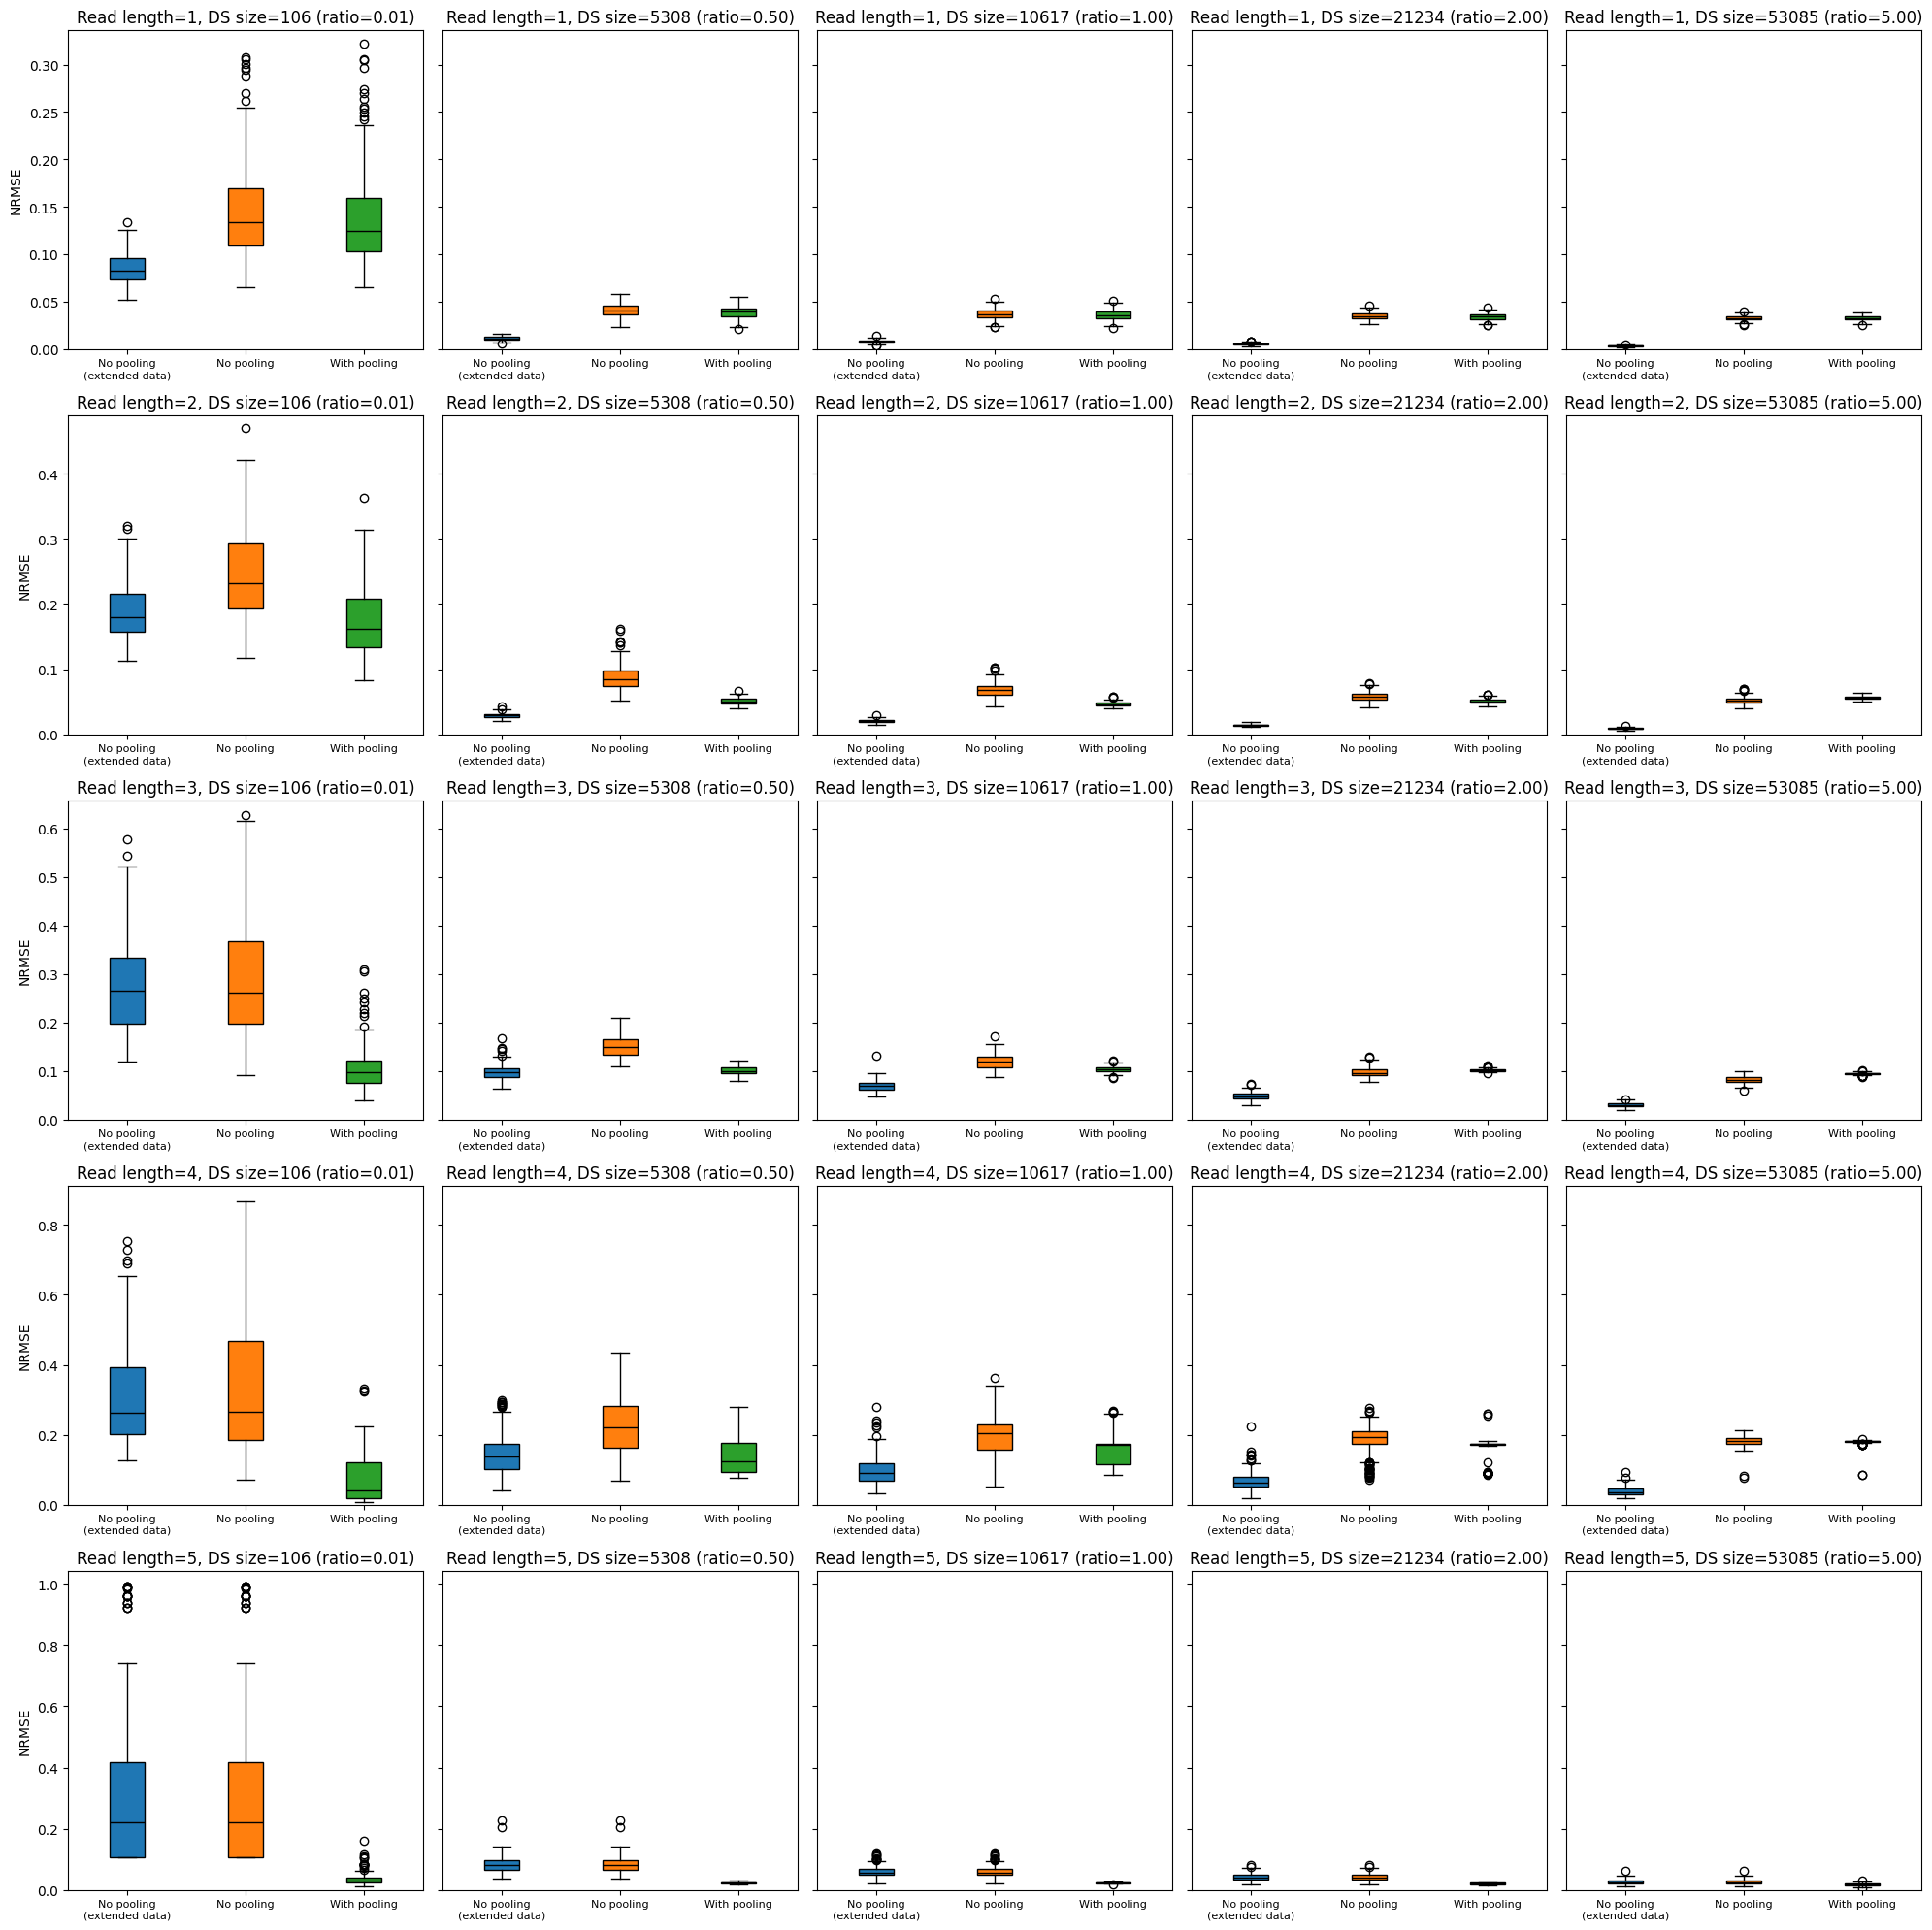

In [28]:
methods = ["naive_sl_without_pooling_complete_data", "naive_sl_without_pooling", "naive_sl_with_pooling"]
method_labels = ["No pooling\n(extended data)", "No pooling", "With pooling"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(5, len(ratio_grid), figsize=(4 * len(ratio_grid), 4 * 5), sharey="row")

for row_idx, read_length in enumerate(range(1, 6)):
    for col_idx, dataset_size in enumerate(dataset_sizes_grid):
        ax = axes[row_idx, col_idx]
        data_to_plot = []
        for method in methods:
            nrmse_list = results_per_size_per_read_length_per_method[dataset_size][read_length][method]
            data_to_plot.append(nrmse_list)

        bp = ax.boxplot(data_to_plot, patch_artist=True, tick_labels=method_labels)

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)

        for median in bp["medians"]:
            median.set_color("black")
            # median.set_linewidth(1.5)

        ax.set_ylim(0, None)
        ax.set_title(f"Read length={read_length}, DS size={dataset_size} (ratio={dataset_size/size_og_dataset:.2f})")
        ax.set_xticklabels(method_labels, rotation=0, fontsize=8)
        ax.set_ylabel("NRMSE" if col_idx == 0 else "")

plt.tight_layout()
plt.show()
